# EDA inicial de Spider 1.0 para Text-to-SQL

Este cuaderno analiza exclusivamente la copia local de Spider disponible en
`../spider_data/spider_data/`. No descarga recursos, no entrena modelos y no modifica
los archivos originales. Las salidas reproducibles se guardan en `eda_outputs/`.

## Alcance y decisiones

* **Entrenamiento oficial:** `train_spider.json` + `train_others.json`.
* **Validación:** `dev.json`.
* **Prueba:** `test.json` se describe por separado porque esta copia contiene SQL gold;
  no debe emplearse para seleccionar modelos, prompts ni hiperparámetros posteriores.
* **Dificultad:** Spider no expone una etiqueta `difficulty` en estos JSON. Se usa un
  puntaje descriptivo propio, documentado en la sección de SQL, sin atribuirlo a Spider.
* **SQL:** se prioriza la representación estructurada `sql`. Los operadores escritos se
  cuentan con expresiones regulares y se reportan como frecuencia léxica.


In [1]:
from pathlib import Path
import json
import math
import re
import sqlite3
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 180)

# The notebook can be launched either from eda_spider/ or from the project root.
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "spider_data" / "spider_data").exists() else cwd.parent
DATA_ROOT = PROJECT_ROOT / "spider_data" / "spider_data"
EDA_ROOT = PROJECT_ROOT / "eda_spider"
FIGURES = EDA_ROOT / "eda_outputs" / "figures"
TABLES = EDA_ROOT / "eda_outputs" / "tables"
for folder in (FIGURES, TABLES):
    folder.mkdir(parents=True, exist_ok=True)

assert DATA_ROOT.exists(), f"No se encontró el dataset local: {DATA_ROOT}"

split_files = {
    "train_spider": "train_spider.json",
    "train_others": "train_others.json",
    "dev": "dev.json",
    "test": "test.json",
}
records = []
for split, filename in split_files.items():
    with (DATA_ROOT / filename).open(encoding="utf-8") as handle:
        rows = json.load(handle)
    for row in rows:
        row = dict(row)
        row["split"] = split
        row["partition"] = "train" if split.startswith("train_") else split
        records.append(row)
examples = pd.DataFrame(records)

with (DATA_ROOT / "tables.json").open(encoding="utf-8") as handle:
    train_dev_schemas = json.load(handle)
with (DATA_ROOT / "test_tables.json").open(encoding="utf-8") as handle:
    test_schemas = json.load(handle)
schema_by_db = {schema["db_id"]: schema for schema in test_schemas}
schema_by_db.update({schema["db_id"]: schema for schema in train_dev_schemas})

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Ejemplos: {len(examples):,}; DB referenciadas: {examples.db_id.nunique():,}")
examples.groupby(["partition", "split"]).size().rename("ejemplos").reset_index()


Proyecto: D:\backup\MAESTRIA\MINE\2026_2\ProcesamientoLenguajeNatural\tareas_equipo\NLP-ml\Proyecto_text_to_sql
Ejemplos: 11,840; DB referenciadas: 206


,partition,split,ejemplos
0,dev,dev,1034
1,test,test,2147
2,train,train_others,1659
3,train,train_spider,7000


## Inventario, estructura y schemas

Se toma el inventario real del directorio local. `tables.json` y `test_tables.json` son la fuente de metadata estructurada; los SQLite se validan sin escritura.

In [2]:
def relpath(path):
    return path.relative_to(PROJECT_ROOT).as_posix()

def folder_size(path):
    if path.is_file():
        return path.stat().st_size
    return sum(item.stat().st_size for item in path.rglob("*") if item.is_file())

def purpose(name):
    known = {
        "train_spider.json": "Ejemplos principales de entrenamiento Spider.",
        "train_others.json": "Ejemplos de entrenamiento procedentes de seis conjuntos previos.",
        "dev.json": "Ejemplos de validación/desarrollo.",
        "test.json": "Ejemplos de prueba; esta copia incluye SQL gold.",
        "tables.json": "Schemas estructurados de bases de train/dev.",
        "test_tables.json": "Schemas estructurados de bases de prueba y cobertura ampliada.",
        "database": "SQLite de train/dev.",
        "test_database": "SQLite de prueba.",
        "README.txt": "Documentación y citas de la distribución local.",
    }
    return known.get(name, "Archivo auxiliar del dataset local.")

top_items = sorted(DATA_ROOT.iterdir(), key=lambda item: (not item.is_dir(), item.name.lower()))
inventory = pd.DataFrame([{
    "archivo_carpeta": relpath(item),
    "tipo": "carpeta" if item.is_dir() else item.suffix.lower().lstrip(".") or "archivo",
    "tamano_bytes": folder_size(item),
    "tamano_mib": round(folder_size(item) / 1024 ** 2, 2),
    "proposito": purpose(item.name),
} for item in top_items])
inventory.to_csv(TABLES / "inventory.csv", index=False, encoding="utf-8")
display(inventory)

field_rows = []
first = examples.iloc[0]
field_meanings = {
    "db_id": "Identificador de la base de datos cuyo schema y SQLite contextualizan la consulta.",
    "question": "Pregunta original en lenguaje natural.",
    "question_toks": "Tokenización provista por Spider de la pregunta.",
    "query": "Consulta SQL gold en texto.",
    "query_toks": "Tokenización SQL con valores literales.",
    "query_toks_no_value": "Tokenización SQL donde valores se sustituyen por value.",
    "sql": "Representación estructurada de la consulta SQL usada por el dataset.",
}
for field in ["db_id", "question", "question_toks", "query", "query_toks", "query_toks_no_value", "sql"]:
    values = examples[field]
    field_rows.append({
        "campo": field,
        "tipo_python": type(first[field]).__name__,
        "significado": field_meanings[field],
        "valores": len(values),
        "nulos": int(values.isna().sum()),
        "ejemplo": json.dumps(first[field], ensure_ascii=False) if isinstance(first[field], (list, dict)) else first[field],
    })
fields = pd.DataFrame(field_rows)
fields.to_csv(TABLES / "example_fields.csv", index=False, encoding="utf-8")
display(fields[["campo", "tipo_python", "significado", "valores", "nulos", "ejemplo"]])

schema_rows, table_rows, primary_key_rows, foreign_key_rows, type_counts = [], [], [], [], Counter()
for db_id, schema in schema_by_db.items():
    table_names = schema["table_names_original"]
    columns = schema["column_names_original"]
    per_table = Counter(table_idx for table_idx, _ in columns if table_idx >= 0)
    for column_type, (table_idx, _) in zip(schema["column_types"], columns):
        if table_idx >= 0:
            type_counts[column_type] += 1
    schema_rows.append({
        "db_id": db_id,
        "n_tablas": len(table_names),
        "n_columnas_reales": sum(1 for table_idx, _ in columns if table_idx >= 0),
        "n_claves_primarias": len(schema["primary_keys"]),
        "n_claves_foraneas": len(schema["foreign_keys"]),
        "columnas_por_tabla_media": round(np.mean(list(per_table.values())), 3) if per_table else 0,
    })
    for idx, table_name in enumerate(table_names):
        table_rows.append({
            "db_id": db_id,
            "tabla": table_name,
            "n_columnas": per_table[idx],
            "esquema": "train_dev" if db_id in {x["db_id"] for x in train_dev_schemas} else "test",
        })
    for column_idx in schema["primary_keys"]:
        table_idx, column_name = columns[column_idx]
        primary_key_rows.append({
            "db_id": db_id,
            "tabla": table_names[table_idx],
            "columna_pk": column_name,
        })
    for source_idx, target_idx in schema["foreign_keys"]:
        source_table_idx, source_column = columns[source_idx]
        target_table_idx, target_column = columns[target_idx]
        foreign_key_rows.append({
            "db_id": db_id,
            "tabla_origen": table_names[source_table_idx],
            "columna_origen": source_column,
            "tabla_destino": table_names[target_table_idx],
            "columna_destino": target_column,
        })
schema_summary = pd.DataFrame(schema_rows).sort_values("db_id")
schema_tables = pd.DataFrame(table_rows).sort_values(["db_id", "tabla"])
schema_types = pd.DataFrame(type_counts.most_common(), columns=["tipo_columna", "columnas"])
primary_keys = pd.DataFrame(primary_key_rows).sort_values(["db_id", "tabla", "columna_pk"])
foreign_keys = pd.DataFrame(foreign_key_rows).sort_values(["db_id", "tabla_origen", "columna_origen"])
schema_summary.to_csv(TABLES / "schema_by_database.csv", index=False, encoding="utf-8")
schema_tables.to_csv(TABLES / "schema_by_table.csv", index=False, encoding="utf-8")
schema_types.to_csv(TABLES / "schema_column_types.csv", index=False, encoding="utf-8")
primary_keys.to_csv(TABLES / "schema_primary_keys.csv", index=False, encoding="utf-8")
foreign_keys.to_csv(TABLES / "schema_foreign_key_relations.csv", index=False, encoding="utf-8")
display(schema_summary.describe().T)


,archivo_carpeta,tipo,tamano_bytes,tamano_mib,proposito
0,spider_data/spider_data/database,carpeta,879487608,838.74,SQLite de train/dev.
1,spider_data/spider_data/test_database,carpeta,906468841,864.48,SQLite de prueba.
2,spider_data/spider_data/.DS_Store,archivo,8196,0.01,Archivo auxiliar del dataset local.
3,spider_data/spider_data/dev.json,json,3629512,3.46,Ejemplos de validación/desarrollo.
4,spider_data/spider_data/dev_gold.sql,sql,124056,0.12,Archivo auxiliar del dataset local.
5,spider_data/spider_data/README.txt,txt,5944,0.01,Documentación y citas de la distribución local.
6,spider_data/spider_data/tables.json,json,810971,0.77,Schemas estructurados de bases de train/dev.
7,spider_data/spider_data/test.json,json,7801951,7.44,Ejemplos de prueba; esta copia incluye SQL gold.
8,spider_data/spider_data/test_gold.sql,sql,274612,0.26,Archivo auxiliar del dataset local.
9,spider_data/spider_data/test_tables.json,json,760941,0.73,Schemas estructurados de bases de prueba y cobertura ampliada.


,campo,tipo_python,significado,valores,nulos,ejemplo
0,db_id,str,Identificador de la base de datos cuyo schema y SQLite contextualizan la consulta.,11840,0,department_management
1,question,str,Pregunta original en lenguaje natural.,11840,0,How many heads of the departments are older than 56 ?
2,question_toks,list,Tokenización provista por Spider de la pregunta.,11840,0,"[""How"", ""many"", ""heads"", ""of"", ""the"", ""departments"", ""are"", ""older"", ""than"", ""56"", ""?""]"
3,query,str,Consulta SQL gold en texto.,11840,0,SELECT count(*) FROM head WHERE age > 56
4,query_toks,list,Tokenización SQL con valores literales.,11840,0,"[""SELECT"", ""count"", ""("", ""*"", "")"", ""FROM"", ""head"", ""WHERE"", ""age"", "">"", ""56""]"
5,query_toks_no_value,list,Tokenización SQL donde valores se sustituyen por value.,11840,0,"[""select"", ""count"", ""("", ""*"", "")"", ""from"", ""head"", ""where"", ""age"", "">"", ""value""]"
6,sql,dict,Representación estructurada de la consulta SQL usada por el dataset.,11840,0,"{""from"": {""table_units"": [[""table_unit"", 1]], ""conds"": []}, ""select"": [false, [[3, [0, [0, 0, false], null]]]], ""where"": [[false, 3, [0, [0, 10, false], null], 56.0, null]], ""g..."


,count,mean,std,min,25%,50%,75%,max
n_tablas,206.0,5.126214,3.706763,2.0,3.0,4.00,6.750,26.000
n_columnas_reales,206.0,25.669903,28.304232,5.0,13.0,19.00,28.000,352.000
n_claves_primarias,206.0,4.611650,3.236177,0.0,3.0,3.00,5.000,18.000
n_claves_foraneas,206.0,4.563107,4.542847,0.0,2.0,3.00,6.000,25.000
columnas_por_tabla_media,206.0,5.048505,1.765847,2.0,4.0,4.75,5.818,14.333


## Dimensiones, preguntas y SQL

Los tokens son los provistos por Spider. Los términos frecuentes se limitan a tokens alfabéticos ASCII y no eliminan stopwords: es una caracterización inicial, no un análisis lingüístico profundo.

In [3]:
KEYWORDS = ["SELECT", "FROM", "WHERE", "JOIN", "GROUP BY", "HAVING", "ORDER BY", "LIMIT"]
AGGREGATIONS = ["COUNT", "SUM", "AVG", "MIN", "MAX"]

def is_sql_dict(value):
    return isinstance(value, dict) and {"select", "from", "where"}.issubset(value)

def nested_sqls(value):
    """Yield nested structured SELECT objects, excluding the root passed by the caller."""
    if isinstance(value, dict):
        for child in value.values():
            if is_sql_dict(child):
                yield child
                yield from nested_sqls(child)
            else:
                yield from nested_sqls(child)
    elif isinstance(value, list):
        for child in value:
            if is_sql_dict(child):
                yield child
                yield from nested_sqls(child)
            else:
                yield from nested_sqls(child)

def tables_in_sql(sql):
    tables = []
    for query in [sql, *list(nested_sqls(sql))]:
        for unit in query.get("from", {}).get("table_units", []):
            if isinstance(unit, list) and len(unit) == 2 and unit[0] == "table_unit":
                tables.append(unit[1])
    return sorted(set(tables))

def atomic_conditions(sql):
    queries = [sql, *list(nested_sqls(sql))]
    return sum(
        sum(isinstance(item, list) for item in query.get("where", []))
        + sum(isinstance(item, list) for item in query.get("having", []))
        + sum(isinstance(item, list) for item in query.get("from", {}).get("conds", []))
        for query in queries
    )

def join_predicates(sql):
    # Spider often encodes joins as conditions under FROM instead of literal JOIN syntax.
    return sum(sum(isinstance(item, list) for item in query.get("from", {}).get("conds", []))
               for query in [sql, *list(nested_sqls(sql))])

def keyword_count(query, keyword):
    return len(re.findall(r"(?<![A-Za-z_])" + re.escape(keyword) + r"(?![A-Za-z_])", query, flags=re.I))

def sql_features(row):
    sql = row.sql
    subqueries = len(list(nested_sqls(sql)))
    table_ids = tables_in_sql(sql)
    row_out = {
        "question_chars": len(row.question),
        "question_tokens": len(row.question_toks),
        "sql_chars": len(row.query),
        "sql_tokens": len(row.query_toks),
        "tables_used": len(table_ids),
        "table_ids": ",".join(map(str, table_ids)),
        "conditions": atomic_conditions(sql),
        "join_predicates_from": join_predicates(sql),
        "subqueries": subqueries,
        "set_operations": sum(value is not None for value in (sql.get("intersect"), sql.get("union"), sql.get("except"))),
    }
    for keyword in KEYWORDS + AGGREGATIONS:
        row_out[keyword] = keyword_count(row.query, keyword)
    row_out["complexity_score"] = (
        row_out["tables_used"] + row_out["join_predicates_from"] + row_out["conditions"]
        + int(row_out["GROUP BY"] > 0) + int(row_out["HAVING"] > 0)
        + 2 * row_out["subqueries"] + row_out["set_operations"]
    )
    return row_out

features = pd.DataFrame([sql_features(row) for row in examples.itertuples(index=False)])
analysis = pd.concat([examples.drop(columns="sql").reset_index(drop=True), features], axis=1)
analysis["complexity_level"] = pd.cut(
    analysis["complexity_score"], bins=[-1, 2, 5, 8, np.inf],
    labels=["baja (0-2)", "media (3-5)", "alta (6-8)", "muy alta (9+)"],
)
analysis.to_csv(TABLES / "example_sql_features.csv", index=False, encoding="utf-8")

def describe_metric(frame, metric):
    return frame.groupby("partition")[metric].describe(percentiles=[.05, .25, .5, .75, .95]).reset_index()

partition_summary = analysis.groupby(["partition", "split"]).agg(
    ejemplos=("question", "size"), bases=("db_id", "nunique"),
    preguntas_media_tokens=("question_tokens", "mean"), sql_media_tokens=("sql_tokens", "mean"),
).reset_index()
dimensions = pd.DataFrame([{
    "preguntas_totales": len(analysis),
    "preguntas_train_oficial": int((analysis.partition == "train").sum()),
    "preguntas_dev": int((analysis.partition == "dev").sum()),
    "preguntas_test": int((analysis.partition == "test").sum()),
    "bases_en_ejemplos": analysis.db_id.nunique(),
    "schemas_disponibles": len(schema_summary),
    "tablas_totales": int(schema_summary.n_tablas.sum()),
    "columnas_totales": int(schema_summary.n_columnas_reales.sum()),
    "tablas_promedio_por_db": round(schema_summary.n_tablas.mean(), 3),
    "columnas_promedio_por_tabla": round(schema_summary.n_columnas_reales.sum() / schema_summary.n_tablas.sum(), 3),
}])
questions_by_db = analysis.groupby(["partition", "db_id"]).size().rename("preguntas").reset_index().sort_values("preguntas", ascending=False)
question_stats = pd.concat([describe_metric(analysis, "question_chars").assign(medida="caracteres"), describe_metric(analysis, "question_tokens").assign(medida="tokens")])
sql_stats = pd.concat([describe_metric(analysis, "sql_chars").assign(medida="caracteres"), describe_metric(analysis, "sql_tokens").assign(medida="tokens")])
operator_frequency = pd.DataFrame({"operador": KEYWORDS + AGGREGATIONS + ["SUBQUERY", "SET_OPERATION"], "frecuencia": [int(analysis[x].sum()) for x in KEYWORDS + AGGREGATIONS] + [int(analysis.subqueries.sum()), int(analysis.set_operations.sum())]})
complexity = analysis.groupby(["partition", "complexity_level"], observed=False).size().rename("ejemplos").reset_index()

for name, frame in {
    "partition_summary.csv": partition_summary, "dataset_dimensions.csv": dimensions,
    "questions_by_database.csv": questions_by_db, "question_length_statistics.csv": question_stats,
    "sql_length_statistics.csv": sql_stats, "sql_operator_frequency.csv": operator_frequency,
    "complexity_distribution.csv": complexity,
}.items():
    frame.to_csv(TABLES / name, index=False, encoding="utf-8")

token_counter = Counter(token.lower() for tokens in analysis.question_toks for token in tokens if re.fullmatch(r"[A-Za-z]+", token))
frequent_terms = pd.DataFrame(token_counter.most_common(30), columns=["termino", "frecuencia"])
frequent_terms.to_csv(TABLES / "frequent_question_terms.csv", index=False, encoding="utf-8")
extremes = pd.concat([analysis.nsmallest(5, "question_tokens"), analysis.nlargest(5, "question_tokens")]).drop_duplicates(subset=["partition", "db_id", "question", "query"])
extremes[["partition", "db_id", "question", "question_chars", "question_tokens", "query"]].to_csv(TABLES / "question_length_extremes.csv", index=False, encoding="utf-8")

display(dimensions.T)
display(partition_summary)
display(question_stats)
display(sql_stats)
display(operator_frequency)


,0
preguntas_totales,11840.000
preguntas_train_oficial,8659.000
preguntas_dev,1034.000
preguntas_test,2147.000
bases_en_ejemplos,206.000
schemas_disponibles,206.000
tablas_totales,1056.000
columnas_totales,5288.000
tablas_promedio_por_db,5.126
columnas_promedio_por_tabla,5.008


,partition,split,ejemplos,bases,preguntas_media_tokens,sql_media_tokens
0,dev,dev,1034,20,13.743714,18.316248
1,test,test,2147,40,13.845366,18.933861
2,train,train_others,1659,6,9.226040,31.611212
3,train,train_spider,7000,140,14.182286,18.493286


,partition,count,mean,std,min,5%,25%,50%,75%,95%,max,medida
0,dev,1034.0,68.048356,22.719587,18.0,35.0,52.0,66.0,81.75,109.35,174.0,caracteres
1,test,2147.0,69.003260,22.688303,22.0,35.0,54.0,67.0,83.00,110.00,185.0,caracteres
2,train,8659.0,66.592563,24.391738,3.0,31.0,49.0,64.0,82.00,109.00,224.0,caracteres
0,dev,1034.0,13.743714,4.528183,5.0,7.0,10.0,13.0,16.00,22.00,33.0,tokens
1,test,2147.0,13.845366,4.474046,5.0,7.0,11.0,13.0,17.00,22.00,36.0,tokens
2,train,8659.0,13.232706,4.877076,1.0,6.0,10.0,13.0,16.00,22.00,44.0,tokens


,partition,count,mean,std,min,5%,25%,50%,75%,95%,max,medida
0,dev,1034.0,106.693424,60.950584,20.0,34.3,63.0,89.0,138.0,227.0,422.0,caracteres
1,test,2147.0,113.490918,73.186635,22.0,35.3,61.0,93.0,147.0,245.0,608.0,caracteres
2,train,8659.0,122.867190,75.941534,18.0,37.0,64.0,104.0,163.0,268.0,577.0,caracteres
0,dev,1034.0,18.316248,9.788251,4.0,7.0,12.0,16.0,24.0,37.0,63.0,tokens
1,test,2147.0,18.933861,10.839776,4.0,7.0,12.0,16.0,25.0,39.0,75.0,tokens
2,train,8659.0,21.006583,12.367349,4.0,7.0,12.0,18.0,28.0,47.0,90.0,tokens


,operador,frecuencia
0,SELECT,13877
1,FROM,13877
2,WHERE,7465
3,JOIN,7916
4,GROUP BY,2870
5,HAVING,713
6,ORDER BY,2555
7,LIMIT,1694
8,COUNT,4208
9,SUM,426


## Calidad, visualizaciones y ejemplos

Las comprobaciones SQLite usan `mode=ro`. Las figuras se producen solo para las distribuciones solicitadas.

,revision,resultado,detalle
0,Valores faltantes en campos requeridos,0,Suma de nulos pandas.
1,Preguntas duplicadas exactas,134,"Cuenta filas que comparten pregunta, incluso entre DB."
2,SQL duplicado exacto,10029,Cuenta filas que comparten SQL textual.
3,db_id sin schema JSON,0,Ninguno
4,db_id sin SQLite,0,Ninguno
5,Errores al abrir SQLite en solo lectura,0,Ninguno
6,Preguntas con caracteres no ASCII,23,No constituye un error de codificación por sí mismo.
7,Textos no normalizados NFC,0,Revisión conservadora de consistencia Unicode.


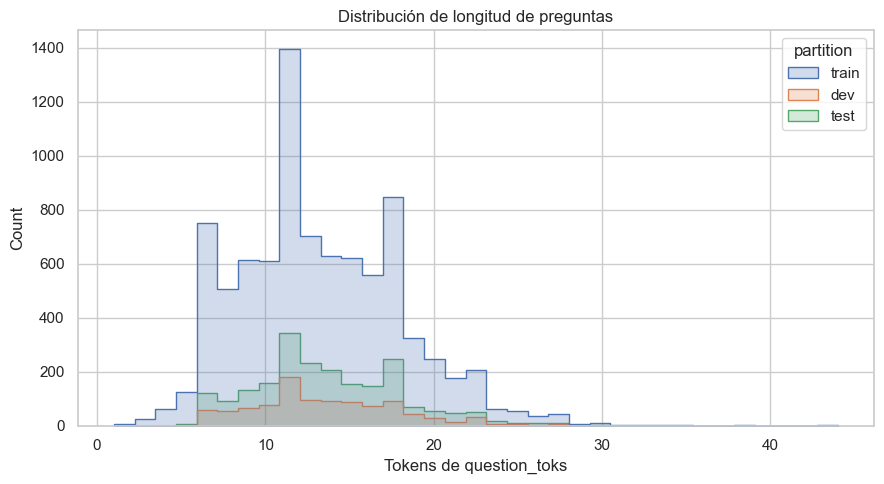

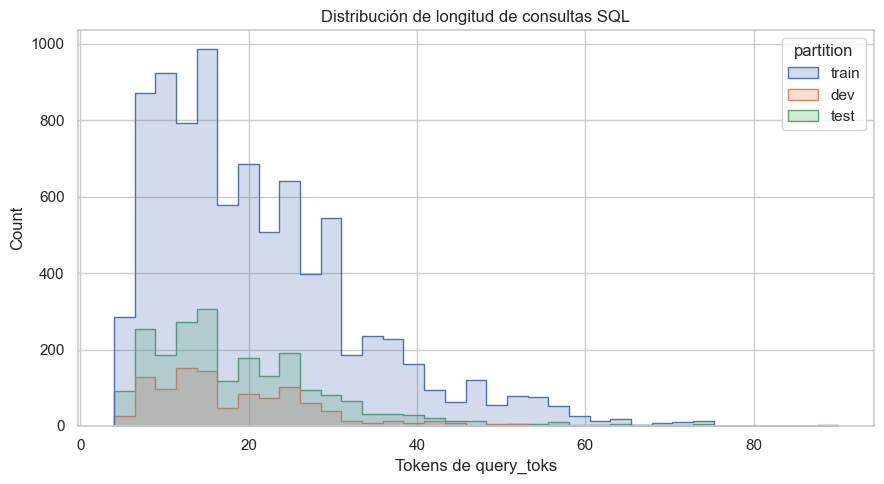

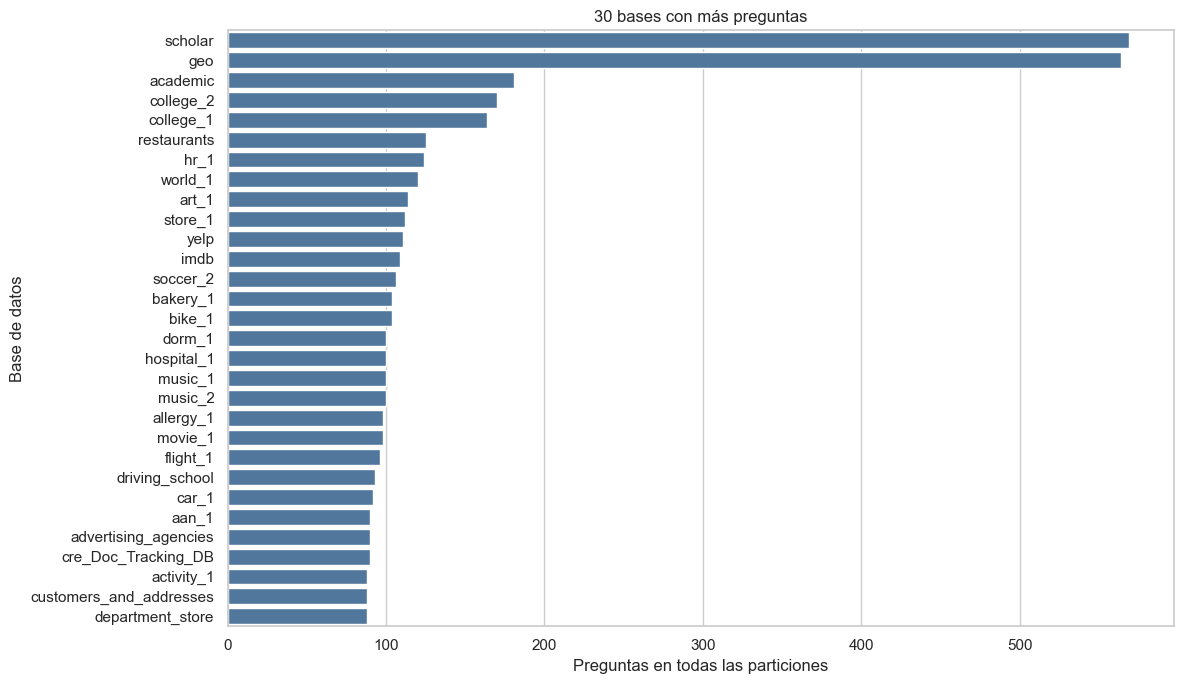

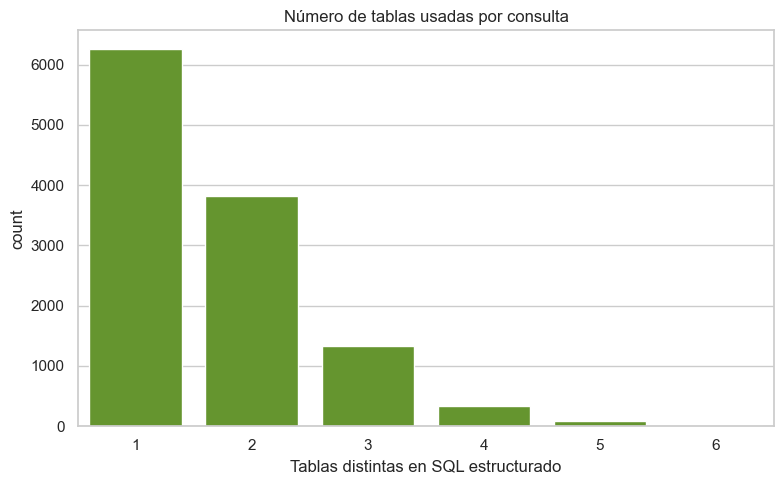

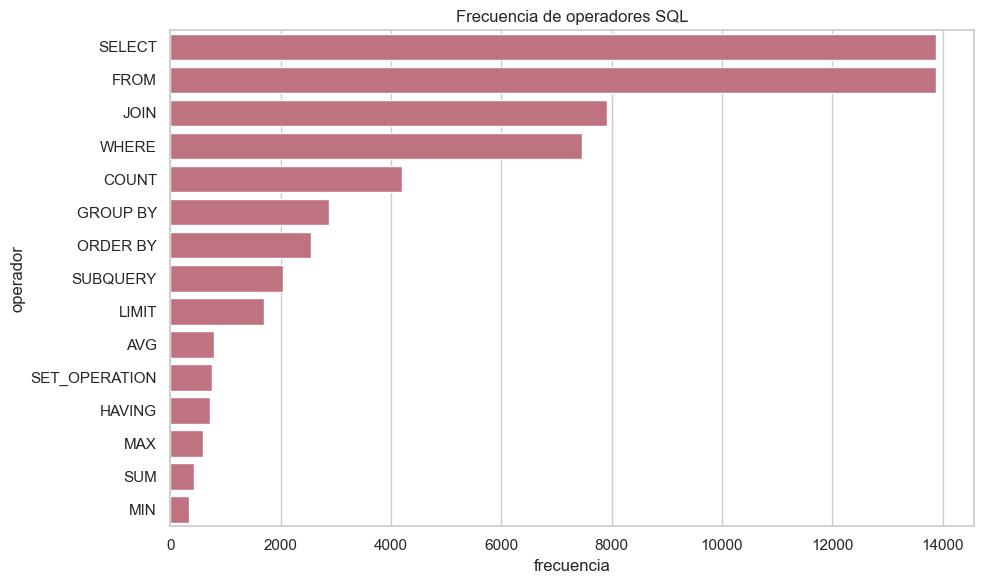

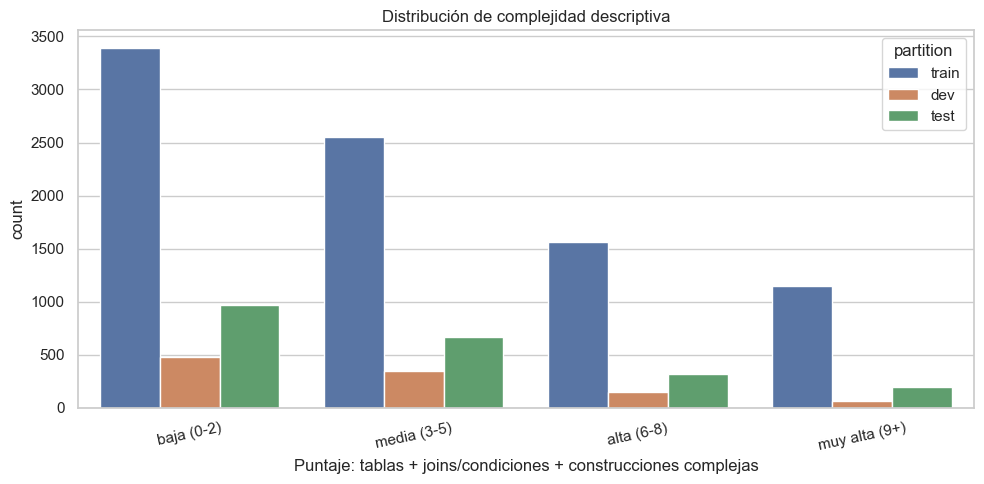

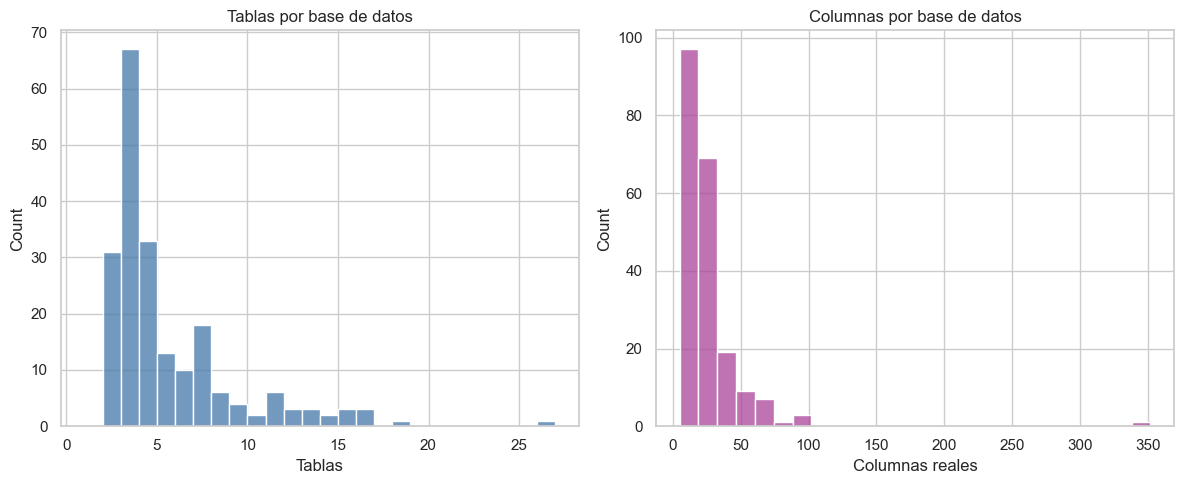

,nivel,db_id,pregunta,sql,puntaje
0,baja,department_management,"List the name, born state and age of the heads of departments ordered by age.","SELECT name , born_state , age FROM head ORDER BY age",1
1,media,academic,return me the papers on PVLDB .,"SELECT t2.title FROM publication AS t2 JOIN journal AS t1 ON t2.jid = t1.jid WHERE t1.name = ""PVLDB"";",5
2,muy_alta,college_1,What are the first names of all students taking accoutning and Computer Information Systems classes?,SELECT T1.stu_fname FROM student AS T1 JOIN enroll AS T2 ON T1.stu_num = T2.stu_num JOIN CLASS AS T3 ON T2.class_code = T3.class_code JOIN course AS T4 ON T3.crs_code = T...,26


In [4]:
# Data-quality checks. SQLite is opened read-only, never written.
schema_ids = set(schema_by_db)
missing_schema = sorted(set(analysis.db_id) - schema_ids)

def sqlite_path(db_id):
    candidates = [DATA_ROOT / "database" / db_id / f"{db_id}.sqlite", DATA_ROOT / "test_database" / db_id / f"{db_id}.sqlite"]
    return next((path for path in candidates if path.exists()), None)

sqlite_missing = sorted(db_id for db_id in analysis.db_id.unique() if sqlite_path(db_id) is None)
sqlite_errors = []
for db_id in analysis.db_id.unique():
    path = sqlite_path(db_id)
    if path:
        try:
            with sqlite3.connect(f"file:{path.as_posix()}?mode=ro", uri=True) as connection:
                connection.execute("SELECT name FROM sqlite_master LIMIT 1").fetchall()
        except sqlite3.Error as error:
            sqlite_errors.append(f"{db_id}: {error}")

required_fields = ["db_id", "question", "question_toks", "query", "query_toks", "query_toks_no_value", "sql"]
quality = pd.DataFrame([
    {"revision": "Valores faltantes en campos requeridos", "resultado": int(examples[required_fields].isna().sum().sum()), "detalle": "Suma de nulos pandas."},
    {"revision": "Preguntas duplicadas exactas", "resultado": int(analysis.question.duplicated(keep=False).sum()), "detalle": "Cuenta filas que comparten pregunta, incluso entre DB."},
    {"revision": "SQL duplicado exacto", "resultado": int(analysis["query"].duplicated(keep=False).sum()), "detalle": "Cuenta filas que comparten SQL textual."},
    {"revision": "db_id sin schema JSON", "resultado": len(missing_schema), "detalle": "; ".join(missing_schema) or "Ninguno"},
    {"revision": "db_id sin SQLite", "resultado": len(sqlite_missing), "detalle": "; ".join(sqlite_missing) or "Ninguno"},
    {"revision": "Errores al abrir SQLite en solo lectura", "resultado": len(sqlite_errors), "detalle": "; ".join(sqlite_errors) or "Ninguno"},
    {"revision": "Preguntas con caracteres no ASCII", "resultado": int(analysis.question.map(lambda x: any(ord(char) > 127 for char in x)).sum()), "detalle": "No constituye un error de codificación por sí mismo."},
    {"revision": "Textos no normalizados NFC", "resultado": int(analysis.question.map(lambda x: unicodedata.normalize("NFC", x) != x).sum()), "detalle": "Revisión conservadora de consistencia Unicode."},
])
quality.to_csv(TABLES / "data_quality_report.csv", index=False, encoding="utf-8")
display(quality)

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIGURES / name, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

plt.figure(figsize=(9, 5))
sns.histplot(data=analysis, x="question_tokens", hue="partition", bins=35, element="step", stat="count", common_norm=False)
plt.title("Distribución de longitud de preguntas")
plt.xlabel("Tokens de question_toks")
savefig("question_token_length_distribution.png")

plt.figure(figsize=(9, 5))
sns.histplot(data=analysis, x="sql_tokens", hue="partition", bins=35, element="step", stat="count", common_norm=False)
plt.title("Distribución de longitud de consultas SQL")
plt.xlabel("Tokens de query_toks")
savefig("sql_token_length_distribution.png")

top_db = questions_by_db.groupby("db_id", as_index=False).preguntas.sum().nlargest(30, "preguntas")
plt.figure(figsize=(12, 7))
sns.barplot(data=top_db, y="db_id", x="preguntas", color="#4477AA")
plt.title("30 bases con más preguntas")
plt.xlabel("Preguntas en todas las particiones")
plt.ylabel("Base de datos")
savefig("questions_per_database_top30.png")

plt.figure(figsize=(8, 5))
sns.countplot(data=analysis, x="tables_used", color="#66A61E")
plt.title("Número de tablas usadas por consulta")
plt.xlabel("Tablas distintas en SQL estructurado")
savefig("tables_used_distribution.png")

plt.figure(figsize=(10, 6))
sns.barplot(data=operator_frequency.sort_values("frecuencia", ascending=False), y="operador", x="frecuencia", color="#CC6677")
plt.title("Frecuencia de operadores SQL")
savefig("sql_operator_frequency.png")

plt.figure(figsize=(10, 5))
sns.countplot(data=analysis, x="complexity_level", hue="partition")
plt.title("Distribución de complejidad descriptiva")
plt.xlabel("Puntaje: tablas + joins/condiciones + construcciones complejas")
plt.xticks(rotation=12)
savefig("complexity_distribution.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(schema_summary.n_tablas, bins=range(1, int(schema_summary.n_tablas.max()) + 2), ax=axes[0], color="#4477AA")
axes[0].set_title("Tablas por base de datos")
axes[0].set_xlabel("Tablas")
sns.histplot(schema_summary.n_columnas_reales, bins=25, ax=axes[1], color="#AA4499")
axes[1].set_title("Columnas por base de datos")
axes[1].set_xlabel("Columnas reales")
savefig("schema_tables_columns_distribution.png")

def schema_labels(db_id, table_ids):
    schema = schema_by_db[db_id]
    names = schema["table_names_original"]
    cols = schema["column_names_original"]
    result = []
    for table_id in table_ids:
        if table_id < len(names):
            columns = [column for idx, column in cols if idx == table_id]
            result.append(f"{names[table_id]} ({', '.join(columns)})")
    relevant_names = {names[table_id] for table_id in table_ids if table_id < len(names)}
    relevant_fks = foreign_keys[(foreign_keys.db_id == db_id) & foreign_keys.tabla_origen.isin(relevant_names) & foreign_keys.tabla_destino.isin(relevant_names)]
    relations = [f"FK: {item.tabla_origen}.{item.columna_origen} -> {item.tabla_destino}.{item.columna_destino}" for item in relevant_fks.itertuples(index=False)]
    return result, relations

# Representative examples are selected deterministically from train/dev only.
candidate = analysis[analysis.partition.isin(["train", "dev"])]
readable_candidate = candidate[candidate.question_tokens >= 7]
targets = [("baja", readable_candidate.nsmallest(1, "complexity_score").iloc[0]),
           ("media", readable_candidate[readable_candidate.complexity_level == "media (3-5)"].sort_values(["question_tokens", "db_id"]).iloc[0]),
           ("muy_alta", candidate[candidate.complexity_level == "muy alta (9+)"].sort_values(["complexity_score", "question_tokens"], ascending=[False, True]).iloc[0])]
example_md = ["# Ejemplos representativos", "", "Selección determinista por complejidad descriptiva; no son etiquetas oficiales de Spider.", ""]
for level, row in targets:
    table_ids = [int(item) for item in row.table_ids.split(",") if item]
    table_labels, relations = schema_labels(row.db_id, table_ids)
    schema_text = "\n".join(f"- `{label}`" for label in table_labels) or "- No se pudo resolver tabla."
    relation_text = "\n".join(f"- `{relation}`" for relation in relations) or "- No hay relación FK interna entre las tablas usadas."
    example_md.extend([
        f"## Complejidad {level}: puntaje {row.complexity_score}",
        "", "**Pregunta:**", row.question, "", "**Base de datos:**", f"`{row.db_id}`", "",
        "**Schema relevante:**", schema_text, "", "**Relaciones FK relevantes:**", relation_text, "", "**SQL esperado:**", "```sql", row.query, "```", "",
        "La pregunta debe vincularse con los nombres de tablas/columnas del schema y, cuando hay varias tablas, con sus relaciones FK.", "",
    ])
(TABLES / "representative_examples.md").write_text("\n".join(example_md), encoding="utf-8")
display(pd.DataFrame([{"nivel": level, "db_id": row.db_id, "pregunta": row.question, "sql": row.query, "puntaje": row.complexity_score} for level, row in targets]))


## Interpretación metodológica

### Relación pregunta -> base -> schema -> SQL

Cada fila aporta la pregunta y un `db_id`. Ese identificador resuelve un objeto en
`tables.json` (train/dev) o `test_tables.json` (test), que contiene nombres de tablas y
columnas, tipos, claves primarias y foráneas. El mismo `db_id` identifica una base SQLite
local. La salida supervisada es `query`; `sql` representa la misma consulta como estructura
anotada. Por tanto, el modelo debe generar SQL condicionado tanto por la pregunta como por
el schema pertinente, no solo imitar texto SQL.

### Complejidad descriptiva (no oficial)

Como no se encontró un campo de dificultad en los JSON locales, se define:

`puntaje = tablas distintas + predicados FROM + condiciones WHERE/HAVING + I(GROUP BY) + I(HAVING) + 2*subconsultas + operaciones_de_conjunto`

Las categorías son baja (0--2), media (3--5), alta (6--8) y muy alta (9+). Los predicados
de `FROM` se usan como aproximación de joins porque Spider puede representar una unión como
condición implícita, sin la palabra literal `JOIN`. Las frecuencias de palabras clave se
obtienen del SQL textual, mientras que tablas, condiciones y subconsultas se extraen de
`sql` estructurado.

## Implicaciones para el proyecto Text-to-SQL

1. Spider es adecuado porque combina preguntas humanas, SQL gold, schemas heterogéneos y
   bases no solapadas entre particiones, lo que prueba generalización cross-domain.
2. La tarea es: dado `(pregunta, schema de db_id)`, generar una consulta SQL ejecutable y
   semánticamente equivalente a la referencia.
3. Es principalmente *semantic parsing* y generación condicionada de código; incluye
   recuperación/enlazado de schema, no clasificación ni clustering como tarea principal.
4. Además de la pregunta, el modelo requiere tablas, columnas, tipos, PK/FK y dialecto
   SQLite; valores de ejemplo pueden ayudar, con precauciones de privacidad y costo.
5. El schema restringe identificadores válidos y permite resolver ambigüedad y rutas de join.
6. Dificultan la generalización a DB desconocidas, el enlazado léxico imperfecto, joins,
   agregaciones, anidamiento y múltiples SQL equivalentes.
7. Posteriormente son razonables modelos seq2seq condicionados por schema, LLM generativos
   con recuperación de schema, o arquitecturas especializadas con graph/schema linking.
8. Métricas: exact match estructural, execution accuracy en SQLite, validez sintáctica,
   precisión de componentes SQL y tasa de referencias válidas al schema.
9. Entrenar con ambos archivos `train_*`, ajustar decisiones solo con `dev`, y reservar
   `test` para evaluación final. Esta copia local permite EDA del test, no ajuste.
10. Para LADM-COL son transferibles el pipeline pregunta-schema-SQL, serialización de
    metadatos, schema linking, ejecución segura y evaluación; habrá que adaptar vocabulario,
    relaciones catastrales, español y posiblemente PostgreSQL/PostGIS.

## Alternativas metodológicas preliminares

| Alternativa | Modelo/datos | Ventajas | Limitaciones | Costo y viabilidad |
|---|---|---|---|---|
| Generativo con prompting | LLM instructivo, pregunta y schema recuperado/serializado; ejemplos de train como demostraciones | Implementación rápida, fuerte baseline, permite inspección cualitativa | Contexto limitado, costo/inferencia, resultados sensibles al prompt, debe evitarse fuga desde test | Bajo a medio sin entrenamiento; viable si se dispone de modelo local/API institucional y evaluación controlada |
| Fine-tuning seq2seq | T5 o FLAN-T5 pequeño/mediano, train oficial y schema linealizado | Reproducible, control sobre datos, adaptación al dominio | Requiere GPU, preprocesamiento y manejo de identificadores; puede rendir mal en schemas largos | Medio; viable con modelo pequeño, subconjunto inicial y GPU académica |
| Arquitectura especializada | RAT-SQL, PICARD o enfoque encoder con schema graph + decoder SQL; train/dev y relaciones PK/FK | Representa explícitamente schema linking y relaciones; alineado con Spider | Instalación, dependencias y cómputo más complejos; mayor riesgo para una electiva | Medio a alto; viable como reproducción acotada o comparación, no como primer prototipo |
